<a href="https://colab.research.google.com/github/deekshdechamma/DL_skill_developer/blob/main/dl8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 8: Semantic Segmentation Pipeline on Pixel-wise Grids using
custom Dice Loss
● Objective: Construct high-precision spatial localization engines for medical imaging and
autonomous navigation datasets, utilizing advanced boundary overlap losses.
● Required Tech Stack: PyTorch, TorchVision, Albumentations, Matplotlib.
● Task Description: Build a deep U-Net architecture for segmenting complex image masks.
Students must implement a custom composite loss function combining Soft Dice Loss and
Binary Cross-Entropy, write dataset pipelines parsing large spatial target masks, and plot
pixel-wise precision-recall boundary curves.

In [ ]:
!pip install -q albumentations opencv-python-headless scikit-learn

In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import precision_recall_curve, average_precision_score

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "lucasiturriago/oxfordiiitpet"
)

print("Dataset path:")
print(path)

Using Colab cache for faster access to the 'oxfordiiitpet' dataset.
Dataset path:
/kaggle/input/oxfordiiitpet


In [ ]:
import os

print(os.listdir(path))

['Valid', 'Test', 'Train']


In [ ]:
for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("--------------------")

/kaggle/input/oxfordiiitpet
Folders: ['Valid', 'Test', 'Train']
Files: []
--------------------
/kaggle/input/oxfordiiitpet/Valid
Folders: ['masks', 'patches']
Files: []
--------------------
/kaggle/input/oxfordiiitpet/Valid/masks
Folders: ['class_0']
Files: []
--------------------
/kaggle/input/oxfordiiitpet/Valid/masks/class_0
Folders: []
Files: ['sample_149.png', 'sample_225.png', 'sample_106.png', 'sample_117.png', 'sample_238.png']
--------------------
/kaggle/input/oxfordiiitpet/Valid/patches
Folders: []
Files: ['sample_149.png', 'sample_225.png', 'sample_106.png', 'sample_117.png', 'sample_238.png']
--------------------
/kaggle/input/oxfordiiitpet/Test
Folders: ['masks', 'patches']
Files: []
--------------------
/kaggle/input/oxfordiiitpet/Test/masks
Folders: ['class_0']
Files: []
--------------------
/kaggle/input/oxfordiiitpet/Test/masks/class_0
Folders: []
Files: ['sample_149.png', 'sample_225.png', 'sample_106.png', 'sample_117.png', 'sample_238.png']
--------------------
/ka

In [ ]:
import os

for root, dirs, files in os.walk(path):
    if len(files) > 0:
        print(root, "->", len(files), "files")

/kaggle/input/oxfordiiitpet/Valid/masks/class_0 -> 256 files
/kaggle/input/oxfordiiitpet/Valid/patches -> 256 files
/kaggle/input/oxfordiiitpet/Test/masks/class_0 -> 256 files
/kaggle/input/oxfordiiitpet/Test/patches -> 256 files
/kaggle/input/oxfordiiitpet/Train/masks/class_0 -> 1024 files
/kaggle/input/oxfordiiitpet/Train/patches -> 1024 files


In [ ]:
import os

# The error 'FileNotFoundError' occurred because 'train.zip' and 'train_masks.zip'
# do not exist directly under the downloaded dataset path.
# The 'oxfordiiitpet' dataset, when downloaded via Kagglehub, is typically
# already unzipped and organized into 'Train', 'Test', and 'Valid' directories,
# which further contain 'patches' (images) and 'masks/class_0' (segmentation masks).

# Therefore, there's no need to perform an unzipping operation.
# We can directly work with the directories provided by 'path'.

# The 'extract_path' variable was likely intended for a different dataset
# (like the Carvana dataset, suggested by the name "/content/carvana")
# or for consolidating data. Since no zips are extracted, '/content/carvana'
# would remain empty unless files are explicitly copied there.

# For clarity and consistency, we'll set a variable to the root of the already
# extracted dataset. Subsequent steps can use this to access images and masks.
extracted_data_root = path

print("Dataset is already extracted. The root of the extracted data is:")
print(extracted_data_root)

print("\nContent of the extracted data root:")
print(os.listdir(extracted_data_root))

# Example of how to access the training image and mask directories:
train_images_dir = os.path.join(extracted_data_root, "Train", "patches")
train_masks_dir = os.path.join(extracted_data_root, "Train", "masks", "class_0")

print(f"\nTrain images are in: {train_images_dir}")
print(f"Train masks are in: {train_masks_dir}")

Dataset is already extracted. The root of the extracted data is:
/kaggle/input/oxfordiiitpet

Content of the extracted data root:
['Valid', 'Test', 'Train']

Train images are in: /kaggle/input/oxfordiiitpet/Train/patches
Train masks are in: /kaggle/input/oxfordiiitpet/Train/masks/class_0


In [ ]:
import os

print("Dataset location:", path)

for root, dirs, files in os.walk(path):
    if len(files) > 0:
        print(root, "->", len(files), "files")

Dataset location: /kaggle/input/oxfordiiitpet
/kaggle/input/oxfordiiitpet/Valid/masks/class_0 -> 256 files
/kaggle/input/oxfordiiitpet/Valid/patches -> 256 files
/kaggle/input/oxfordiiitpet/Test/masks/class_0 -> 256 files
/kaggle/input/oxfordiiitpet/Test/patches -> 256 files
/kaggle/input/oxfordiiitpet/Train/masks/class_0 -> 1024 files
/kaggle/input/oxfordiiitpet/Train/patches -> 1024 files


In [ ]:
#Step 7 — Find image and mask files automatically
image_files = []
mask_files = []

# Assuming 'path' is the extracted_data_root from previous steps
# e.g., '/root/.cache/kagglehub/datasets/lucasiturriago/oxfordiiitpet/versions/3'

for root, dirs, files in os.walk(path):
    for file in files:
        # Both images and masks in this dataset are PNGs. Distinguish them by directory.
        if file.lower().endswith(".png"):
            full_path = os.path.join(root, file)

            # Files in 'patches' directories are images
            if "patches" in root:
                image_files.append(full_path)
            # Files in 'masks/class_0' directories are masks
            elif "masks/class_0" in root:
                mask_files.append(full_path)

print("Images found:", len(image_files))
print("Masks found:", len(mask_files))

print("\nExample image:")
print(image_files[0] if image_files else "No image found")

print("\nExample mask:")
print(mask_files[0] if mask_files else "No mask found")

Images found: 1536
Masks found: 1536

Example image:
/kaggle/input/oxfordiiitpet/Valid/patches/sample_149.png

Example mask:
/kaggle/input/oxfordiiitpet/Valid/masks/class_0/sample_149.png


In [ ]:
#Step 8 — Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import precision_recall_curve

In [ ]:
!pip install -q albumentations scikit-learn

In [ ]:
#Step 9 — Transform
transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
#Step 10 — Pair images and masks

# Re-initializing image_files and mask_files to ensure they are current
# as there was an issue where they seemed to be reset or corrupted
# between previous cells.
image_files = []
mask_files = []

# Re-run the file finding logic to populate image_files and mask_files
# based on the dataset structure, assuming 'path' is still valid.
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(".png"):
            full_path = os.path.join(root, file)
            if "patches" in root:
                image_files.append(full_path)
            elif "masks/class_0" in root:
                mask_files.append(full_path)


def get_name(filepath):
    name = os.path.basename(filepath)
    name = os.path.splitext(name)[0]

    name = name.replace("_mask", "")
    name = name.replace("_trimap", "")

    return name


image_dict = {
    get_name(x): x
    for x in image_files
}

mask_dict = {
    get_name(x): x
    for x in mask_files
}

common_names = sorted(
    set(image_dict.keys()) &
    set(mask_dict.keys())
)

print("Images found (re-checked):", len(image_files))
print("Masks found (re-checked):", len(mask_files))
print("Matched image-mask pairs:", len(common_names))

Images found (re-checked): 1536
Masks found (re-checked): 1536
Matched image-mask pairs: 1024


In [ ]:
#Step 11 — Dataset class
class PetDataset(Dataset):

    def __init__(
        self,
        names,
        image_dict,
        mask_dict,
        transform=None
    ):

        self.names = names
        self.image_dict = image_dict
        self.mask_dict = mask_dict
        self.transform = transform

    def __len__(self):

        return len(self.names)

    def __getitem__(self, index):

        name = self.names[index]

        image_path = self.image_dict[name]
        mask_path = self.mask_dict[name]

        # Read image
        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # Read mask
        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Convert mask to binary
        mask = (mask > 0).astype(
            np.float32
        )

        # Transform
        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        mask = mask.unsqueeze(0)

        return image.float(), mask.float()

In [ ]:
#Step 12 — Use a smaller subset
common_names = common_names[:1000]

dataset = PetDataset(
    common_names,
    image_dict,
    mask_dict,
    transform
)

print("Dataset size:", len(dataset))

Dataset size: 1000


In [ ]:
#Step 13 — Train/validation split
train_size = int(
    0.8 * len(dataset)
)

val_size = (
    len(dataset) - train_size
)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))

Training: 800
Validation: 200


In [ ]:
#Step 14 — DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

print("DataLoaders created!")

DataLoaders created!


In [ ]:
#Step 15 — Check image and mask

images, masks = next(
    iter(train_loader)
)

print("Image shape:", images.shape)
print("Mask shape:", masks.shape)

print("Mask min:", masks.min())
print("Mask max:", masks.max())

Image shape: torch.Size([8, 3, 128, 128])
Mask shape: torch.Size([8, 1, 128, 128])
Mask min: tensor(0.)
Mask max: tensor(1.)


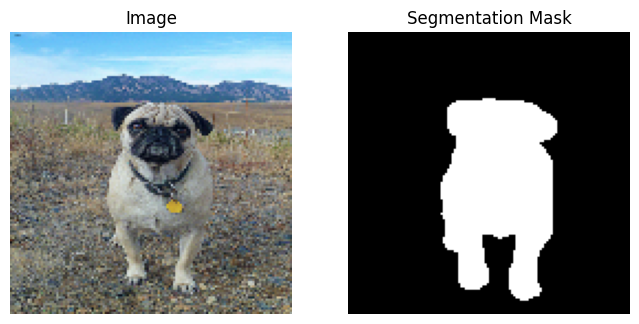

In [ ]:
#Step 16 — Display sample
image = images[0].permute(
    1, 2, 0
).numpy()

image = (
    image - image.min()
) / (
    image.max() - image.min() + 1e-8
)

mask = masks[0][0].numpy()

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)

plt.imshow(image)

plt.title("Image")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    mask,
    cmap="gray"
)

plt.title("Segmentation Mask")

plt.axis("off")

plt.show()

In [ ]:
#Step 17 — Simple U-Net block
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

In [ ]:
#Step 18 — Simple U-Net
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.enc1 = DoubleConv(
            3, 32
        )

        self.enc2 = DoubleConv(
            32, 64
        )

        self.enc3 = DoubleConv(
            64, 128
        )

        self.pool = nn.MaxPool2d(2)


        # Bottleneck

        self.bottleneck = DoubleConv(
            128, 256
        )


        # Decoder

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )


        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )


        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )


        self.output = nn.Conv2d(
            32,
            1,
            1
        )


    def forward(self, x):

        # Encoder

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )


        # Bottleneck

        b = self.bottleneck(
            self.pool(e3)
        )


        # Decoder

        d3 = self.up3(b)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)


        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)


        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)


        return self.output(d1)

In [ ]:
#Step 19 — Create model
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

model = UNet().to(device)

Device: cpu


In [ ]:
test_input = torch.randn(
    1, 3, 128, 128
).to(device)

with torch.no_grad():

    test_output = model(
        test_input
    )

print(
    "Input:",
    test_input.shape
)

print(
    "Output:",
    test_output.shape
)

Input: torch.Size([1, 3, 128, 128])
Output: torch.Size([1, 1, 128, 128])


In [ ]:
#Step 20 — Custom Dice Loss
class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(
        self,
        prediction,
        target
    ):

        prediction = torch.sigmoid(
            prediction
        )

        prediction = prediction.view(-1)
        target = target.view(-1)

        intersection = (
            prediction * target
        ).sum()

        dice = (
            2 * intersection + 1
        ) / (
            prediction.sum()
            + target.sum()
            + 1
        )

        return 1 - dice

In [ ]:
#Step 21 — Dice + BCE Loss
class DiceBCELoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.dice = DiceLoss()

        self.bce = (
            nn.BCEWithLogitsLoss()
        )

    def forward(
        self,
        prediction,
        target
    ):

        dice_loss = self.dice(
            prediction,
            target
        )

        bce_loss = self.bce(
            prediction,
            target
        )

        return (
            dice_loss + bce_loss
        )

In [ ]:
#Step 22 — Optimizer
criterion = DiceBCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and optimizer ready!")

Loss and optimizer ready!


In [ ]:
#Step 23 — Train U-Net
EPOCHS = 3

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        loss = criterion(
            predictions,
            masks
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss /
        len(train_loader)
    )

    train_losses.append(
        average_loss
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/3 Loss: 1.1236
Epoch 2/3 Loss: 0.8993
Epoch 3/3 Loss: 0.8599


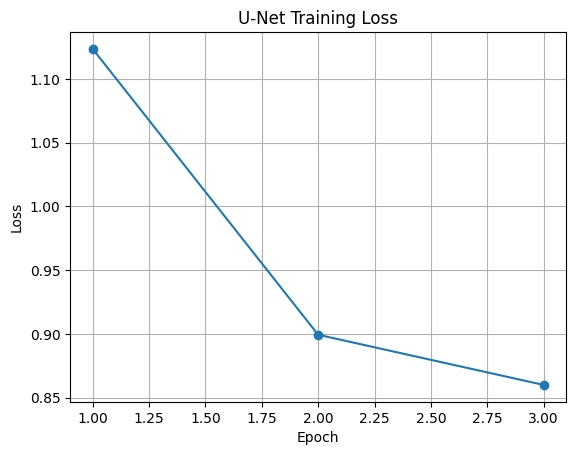

In [79]:
#Step 24 — Plot loss
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "U-Net Training Loss"
)

plt.grid()

plt.show()

In [80]:
#Step 25 — Test prediction
model.eval()

images, masks = next(
    iter(val_loader)
)

test_image = images[0:1].to(
    device
)

with torch.no_grad():

    output = model(
        test_image
    )

    prediction = torch.sigmoid(
        output
    )

    prediction = (
        prediction > 0.5
    ).float()

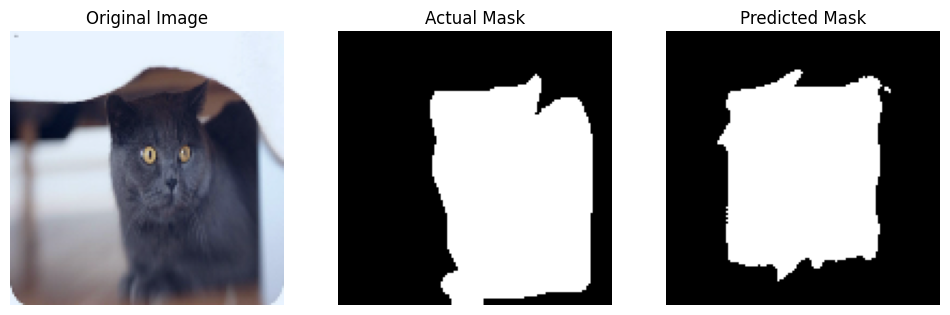

In [81]:
#Step 26 — Show predicted mask
image = images[0].permute(
    1, 2, 0
).numpy()

image = (
    image - image.min()
) / (
    image.max() - image.min() + 1e-8
)

actual_mask = (
    masks[0][0].numpy()
)

predicted_mask = (
    prediction[0][0]
    .cpu()
    .numpy()
)


plt.figure(
    figsize=(12, 4)
)


plt.subplot(1, 3, 1)

plt.imshow(image)

plt.title("Original Image")

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    actual_mask,
    cmap="gray"
)

plt.title("Actual Mask")

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    predicted_mask,
    cmap="gray"
)

plt.title("Predicted Mask")

plt.axis("off")


plt.show()

In [82]:
#Step 27 — Precision-Recall data
all_true = []
all_pred = []

model.eval()

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(
            outputs
        )

        all_pred.append(
            probabilities
            .cpu()
            .numpy()
            .reshape(-1)
        )

        all_true.append(
            masks
            .numpy()
            .reshape(-1)
        )


all_pred = np.concatenate(
    all_pred
)

all_true = np.concatenate(
    all_true
)

print("Pixels:", len(all_true))

Pixels: 3276800


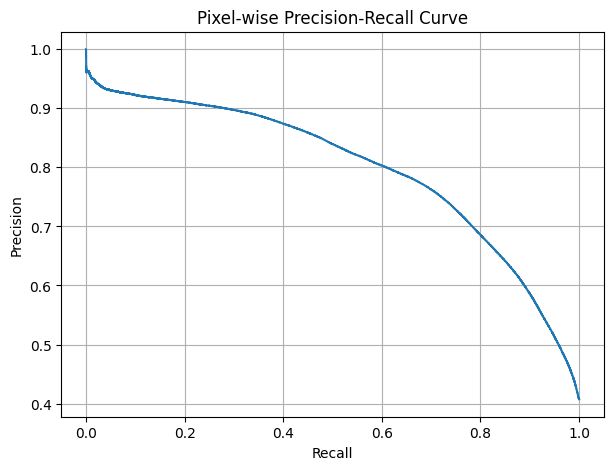

In [83]:
#Step 28 — Pixel-wise Precision-Recall curve
precision, recall, thresholds = (
    precision_recall_curve(
        all_true,
        all_pred
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Pixel-wise Precision-Recall Curve"
)

plt.grid()

plt.show()

In [84]:
#Step 29 — Dice Score
binary_pred = (
    all_pred > 0.5
).astype(np.float32)

intersection = (
    binary_pred * all_true
).sum()

dice_score = (
    2 * intersection + 1
) / (
    binary_pred.sum()
    + all_true.sum()
    + 1
)

print(
    "Dice Score:",
    round(
        float(dice_score),
        4
    )
)

Dice Score: 0.6952


In [85]:
#Step 30 — Save model
torch.save(
    model.state_dict(),
    "task8_unet.pth"
)

print(
    "Model saved successfully!"
)

Model saved successfully!
